In [1]:
import csv

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import sklearn.metrics as metrics

from tensorflow import keras
from keras.callbacks import EarlyStopping
from keras.models import Model, Sequential, load_model, save_model
from keras.layers import Activation, Dense, Input, Dropout, Flatten, BatchNormalization
from keras.optimizers import Adam
from keras.metrics import categorical_crossentropy, Precision, Recall

from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, accuracy_score, precision_score, recall_score, f1_score, precision_recall_fscore_support, ConfusionMatrixDisplay

# Leitura dos registros de treinamento:

In [2]:
csv_path_training_gases = "Datasets/Ibrahim-dataset/Oversampled-119-dataset/train_samples.csv"
with open(csv_path_training_gases, mode = 'r') as file:
    csv_reader_training_gases = csv.reader(file)
    next(csv_reader_training_gases)

    train_samples = []
    for row in csv_reader_training_gases:
        train_samples.append([float(x) for x in row])
        
csv_path_training_faults = "Datasets/Ibrahim-dataset/Oversampled-119-dataset/train_labels.csv"
with open(csv_path_training_faults, mode = 'r') as file:
    csv_reader_training_faults = csv.reader(file)
    next(csv_reader_training_faults)

    train_labels = []
    for row in csv_reader_training_faults:
        train_labels.append(float(row[0]))

# Normalização dos treinos:

In [3]:
# normalização dos gases
train_samples = np.array(train_samples)
train_labels = np.array(train_labels)

# normalização das falhas
train_labels = train_labels.flatten()
int_scaled_train_labels = (train_labels.astype(float)-1).astype(int)
int_scaled_train_labels = np.array(int_scaled_train_labels)

# Criação do modelo da Rede neural:

In [4]:
def create_functional_model():
    model = Sequential([
        Input(shape=(5,)),
        Dense(127, activation='relu'),
        Dropout(0.4),
        Dense(127, activation='relu'),
        Dropout(0.2),
        Dense(127, activation='relu'),
        Dense(127, activation='relu'),
        Dense(7, activation='softmax')
    ]) 

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

early_stopping = EarlyStopping(
    monitor='loss',
    patience=10000,
    mode='min',
    restore_best_weights=True
)

functional_model = create_functional_model()
history = functional_model.fit(train_samples, int_scaled_train_labels, validation_split=0, epochs=8000, batch_size=25, callbacks=[early_stopping], verbose=2)

Epoch 1/8000


InvalidArgumentError: Graph execution error:

Detected at node 'sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits' defined at (most recent call last):
    File "C:\Python\lib\runpy.py", line 197, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "C:\Python\lib\runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "c:\ProjetosIC\JulioAvilaS-FIP-2025-classificacao-automatica-falhas-transformadores-potencia\ambiente_teste\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "c:\ProjetosIC\JulioAvilaS-FIP-2025-classificacao-automatica-falhas-transformadores-potencia\ambiente_teste\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
      app.start()
    File "c:\ProjetosIC\JulioAvilaS-FIP-2025-classificacao-automatica-falhas-transformadores-potencia\ambiente_teste\lib\site-packages\ipykernel\kernelapp.py", li

# Plotagem das métricas de treinamento:

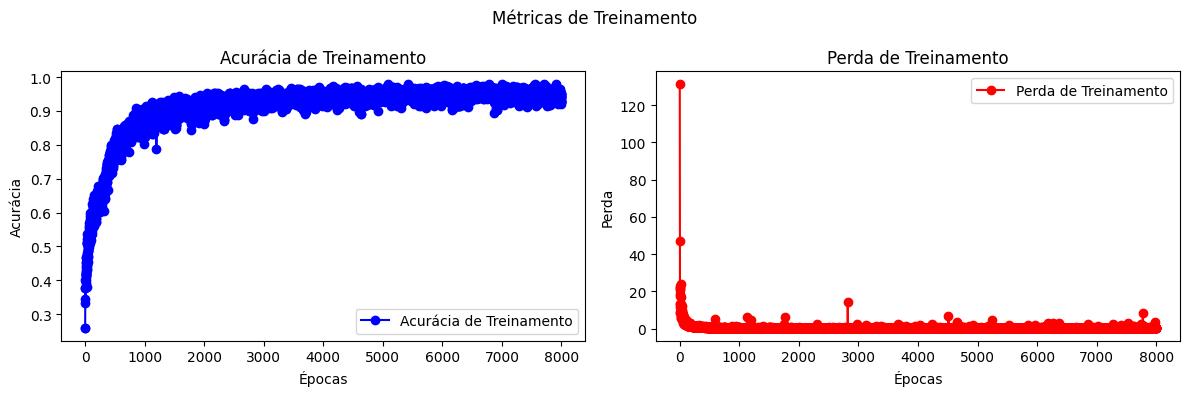

In [ ]:
def plot_training_history(history):
    acc = history.history['accuracy']
    loss = history.history['loss']
    epochs = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Métricas de Treinamento')

    ax1.plot(epochs, acc, 'bo-', label='Acurácia de Treinamento')
    ax1.set_title('Acurácia de Treinamento')
    ax1.set_xlabel('Épocas')
    ax1.set_ylabel('Acurácia')
    ax1.legend()

    ax2.plot(epochs, loss, 'ro-', label='Perda de Treinamento')
    ax2.set_title('Perda de Treinamento')
    ax2.set_xlabel('Épocas')
    ax2.set_ylabel('Perda')
    ax2.legend()

    if 'val_accuracy' in history.history:
        val_acc = history.history['val_accuracy']
        val_loss = history.history['val_loss']
        ax1.plot(epochs, val_acc, 'g-', label='Acurácia de Validação')
        ax2.plot(epochs, val_loss, 'm-', label='Perda de Validação')
        ax1.legend()
        ax2.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

# Leitura dos registros de teste:


In [ ]:
csv_path_testing_gases = "Datasets/Ibrahim-dataset/Oversampled-119-dataset/test_samples.csv"
with open(csv_path_testing_gases, mode = 'r') as file:
    csv_reader_testing_gases = csv.reader(file)
    next(csv_reader_testing_gases)
    
    test_samples = []
    for row in csv_reader_testing_gases:
        test_samples.append([float(x) for x in row])

csv_path_testing_faults = "Datasets/Ibrahim-dataset/Oversampled-119-dataset/test_labels.csv"
with open(csv_path_testing_faults, mode = 'r') as file:
    csv_reader_testing_faults = csv.reader(file)
    next(csv_reader_testing_faults)
    
    test_labels = []
    for row in csv_reader_testing_faults:
        test_labels.append(float(row[0]))

# Normalização dos testes:

In [ ]:
# normalização dos gases de teste
test_samples = np.array(test_samples)
test_labels = np.array(test_labels)

# normalização das falhas de teste
test_labels = test_labels.flatten()
int_scaled_test_labels = (test_labels.astype(float)-1).astype(int)
int_scaled_test_labels = np.array(int_scaled_test_labels)

# Teste e análise do modelo:

4/4 [==============================] - 0s 2ms/step
Balanced Accuracy: 0.8819
Perda no conjunto de teste: 1.4566

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        15
           1       0.92      0.92      0.92        12
           2       0.83      0.88      0.86        17
           3       0.79      0.79      0.79        19
           4       1.00      0.89      0.94        19
           5       0.57      1.00      0.73         4
           6       0.93      0.82      0.87        17

    accuracy                           0.86       103
   macro avg       0.84      0.88      0.85       103
weighted avg       0.88      0.86      0.87       103



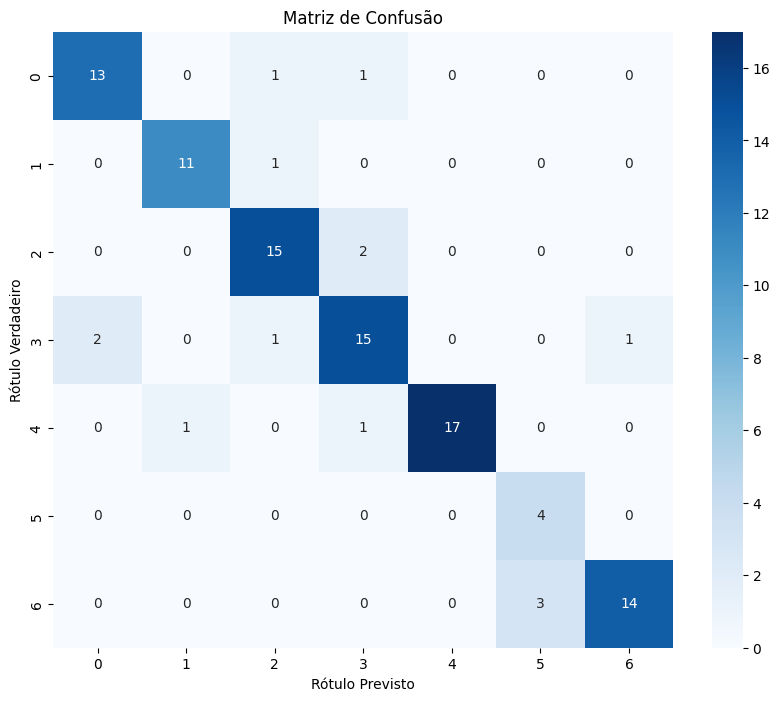

In [ ]:

# realizando predições com o modelo treinado
y_pred = functional_model.predict(test_samples)
y_pred_classes = np.argmax(y_pred, axis=1)

# avaliando o modelo
test_loss, test_accuracy = functional_model.evaluate(test_samples, 
                                                   int_scaled_test_labels, 
                                                   verbose=0)
balanced_acc = balanced_accuracy_score(int_scaled_test_labels, y_pred_classes)
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Perda no conjunto de teste: {test_loss:.4f}")
print("\nRelatório de Classificação:")
print(classification_report(int_scaled_test_labels, y_pred_classes, zero_division=0))

# matriz de confusão
cm = confusion_matrix(int_scaled_test_labels, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.ylabel('Rótulo Verdadeiro')
plt.xlabel('Rótulo Previsto')
plt.show()
